In [1]:
import pickle
import numpy as np
from FastBEMT.Propeller import Propeller
from FastBEMT.JobParameters import LowFidelityParameters

In [ ]:
rpm_values = range(3000, 7500, 500)  # 3000, 3500, 4000, 4500, 5000, 5500, 6000, 6500, 7000
thrust_values_10x5e = []
thrust_values_10x7e = []
thrust_values_10x8e = []

for rpm in rpm_values:
    print(rpm)
    params = LowFidelityParameters(
        rpm=rpm,
        a_inf=343,
        rho=1.225,
        mu=1.81e-5,
        n_blades=2,
        p_ref=2e-5,
        revolutions=100,
        num_obs_times_per_rev=100,
        device='cuda',
    )

    with open("../Datasets/Propellers/10x5E.pkl", "rb") as f:
        blade_dict = pickle.load(f)

    propeller_10x5e = Propeller(
        geometry=blade_dict,
        params=params,
        use_cuda_timing=True,
    )

    with open("../Datasets/Propellers/10x7E.pkl", "rb") as f:
        blade_dict = pickle.load(f)

    propeller_10x7e = Propeller(
        geometry=blade_dict,
        params=params,
        use_cuda_timing=True,
    )

    with open("../Datasets/Propellers/10x7E.pkl", "rb") as f:
        blade_dict = pickle.load(f)

    propeller_10x7e = Propeller(
        geometry=blade_dict,
        params=params,
        use_cuda_timing=True,
    )

    with open("../Datasets/Propellers/10x8E.pkl", "rb") as f:
        blade_dict = pickle.load(f)

    propeller_10x8e = Propeller(
        geometry=blade_dict,
        params=params,
        use_cuda_timing=True,
    )
    
    # Run BEMT
    propeller_10x5e.run_bemt(v_inf=0)
    thrust, _, _ , _  = propeller_10x5e.compute_total_forces()
    thrust_values_10x5e.append(thrust)

    propeller_10x7e.run_bemt(v_inf=0)
    thrust, _, _ , _  = propeller_10x7e.compute_total_forces()
    thrust_values_10x7e.append(thrust)

    propeller_10x8e.run_bemt(v_inf=0)
    thrust, _, _ , _  = propeller_10x8e.compute_total_forces()
    thrust_values_10x8e.append(thrust)

3000
3500
4000
4500
5000
5500
6000
6500
7000


In [ ]:
mean_thrust_10x7e = np.array([1.321277, 1.731331, 2.313578, 2.979274, 3.704298, 4.589624, 5.475130, 6.609976, 7.752219])
std_thrust_10x7e = np.array([0.041742, 0.097682, 0.042499, 0.046986, 0.029013, 0.063586, 0.057441, 0.036956, 0.034880])

In [ ]:
mean_thrust_10x5e = np.array([1.124, 1.521, 2.004, 2.545, 3.235, 3.885, 4.666, 5.554, 6.484])
std_thrust_10x5e  = np.array([0.050, 0.140, 0.106, 0.085, 0.136, 0.150, 0.129, 0.173, 0.270])

In [ ]:
mean_thrust_10x8e = np.array([1.306817, 1.709860, 2.296879, 2.953333, 3.709218, 4.509560, 5.523585, 6.568831, 7.734483])
std_thrust_10x8e = np.array([0.002370, 0.005965, 0.006378, 0.008630, 0.011122, 0.009448, 0.017245, 0.022818, 0.016024])

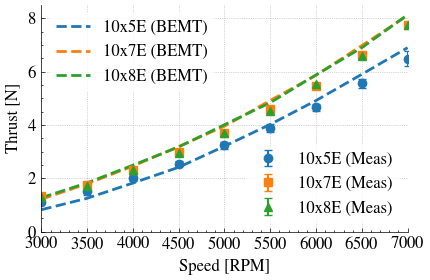

In [ ]:
import matplotlib.pyplot as plt

plt.style.use(['science','no-latex'])
plt.figure(figsize=(4.5, 3))

color_5e = 'tab:blue'
color_7e = 'tab:orange'
color_8e = 'tab:green'

# Plotting logic
p1, = plt.plot(list(rpm_values), thrust_values_10x5e, color=color_5e, linestyle='--', linewidth=2, label='10x5E (BEMT)')
e1 = plt.errorbar(list(rpm_values), mean_thrust_10x5e, yerr=std_thrust_10x5e, 
             color=color_5e, fmt='o', elinewidth=1.5, capsize=3, label='10x5E (Meas)', linewidth=2)

p2, = plt.plot(list(rpm_values), thrust_values_10x7e, color=color_7e, linestyle='--', linewidth=2, label='10x7E (BEMT)')
e2 = plt.errorbar(list(rpm_values), mean_thrust_10x7e, yerr=std_thrust_10x7e, 
             color=color_7e, fmt='s', elinewidth=1.5, capsize=3, label='10x7E (Meas)', linewidth=2)

p3, = plt.plot(list(rpm_values), thrust_values_10x8e, color=color_8e, linestyle='--', linewidth=2, label='10x8E (BEMT)')
e3 = plt.errorbar(list(rpm_values), mean_thrust_10x8e, yerr=std_thrust_10x8e, 
             color=color_8e, fmt='^', elinewidth=1.5, capsize=3, label='10x8E (Meas)', linewidth=2)

# --- SPLIT LEGEND LOGIC ---

# Legend 1: BEMT (Top Left)
# Note: errorbar returns a container, so we use the first element for the legend handle if needed,
# but here we specifically want the line plots (p1, p2, p3).
leg1 = plt.legend([p1, p2, p3], ['10x5E (BEMT)', '10x7E (BEMT)', '10x8E (BEMT)'], 
                  loc='upper left', fontsize=12, frameon=True, edgecolor='none')

# Add the first legend manually so the second one doesn't remove it
plt.gca().add_artist(leg1)

# Legend 2: Measured (Bottom Right)
plt.legend([e1, e2, e3], ['10x5E (Meas)', '10x7E (Meas)', '10x8E (Meas)'], 
           loc='lower right', fontsize=12, frameon=True, edgecolor='none')

# --- FORMATTING ---
plt.xlabel('Speed [RPM]', fontsize=12)
plt.ylabel('Thrust [N]', fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, linestyle=':')
plt.xlim(3000, 7000)
plt.ylim(0)
plt.gca().spines[['top', 'right']].set_visible(False)
plt.gca().tick_params(top=False, right=False, which='both')
plt.tight_layout()
# plt.gca().set_aspect('equal')
plt.savefig('../Figures/BEMT_val.pdf', dpi=200)
plt.show()